In [1]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import PCA
from tqdm import tqdm

# --- CONFIGURATION ---
BIDS_ROOT = r"C:\Users\janak\GitHub\ADHD-MRI-Deep-Learning\ADHD_BIDS"
DOWNSAMPLE_FACTOR = 2  # Set to 1 for full res, 2 or 4 to save RAM
OUTPUT_DIR = "eda_results_ADHD"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. DATA LOADING (Mirroring your original logic)
participants = pd.read_csv(os.path.join(BIDS_ROOT, "participants.tsv"), sep="\t")
images, labels = [], []

print("Searching for NIfTI files...")
for _, row in participants.iterrows():
    sub_id, label = row['participant_id'], (row['label'])
    img_path = os.path.join(BIDS_ROOT, f"sub-{sub_id}", "anat", f"{sub_id}_T1w.nii.gz")
    if os.path.isfile(img_path):
        images.append(img_path)
        labels.append(label)

labels = np.array(labels)
print(f"Found {len(images)} images. ADHD: {sum(labels)}, Control: {len(labels)-sum(labels)}")

Searching for NIfTI files...
Found 896 images. ADHD: 347, Control: 549


In [2]:
# 2. VOXEL-WISE MEAN & STATISTICAL ANALYSIS
def analyze_voxels(image_paths, labels):
    sample_img = nib.load(image_paths[0])
    affine = sample_img.affine
    shape = sample_img.get_fdata()[::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR].shape
    
    # Initialize accumulators to save RAM
    adhd_data = []
    ctrl_data = []
    
    print(f"Loading and downsampling volumes (Factor: {DOWNSAMPLE_FACTOR})...")
    for path, label in tqdm(zip(image_paths, labels), total=len(labels)):
        data = nib.load(path).get_fdata()[::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR]
        if label == 1: adhd_data.append(data)
        else: ctrl_data.append(data)
    
    adhd_data = np.array(adhd_data)
    ctrl_data = np.array(ctrl_data)

    # Calculate Means
    mean_adhd = np.mean(adhd_data, axis=0)
    mean_ctrl = np.mean(ctrl_data, axis=0)
    diff_map = mean_adhd - mean_ctrl

    # Calculate T-test per voxel
    # Null Hypothesis: No difference between groups at voxel(x,y,z)
    print("Calculating voxel-wise t-scores...")
    t_map, p_map = stats.ttest_ind(adhd_data, ctrl_data, axis=0, equal_var=False)
    t_map = np.nan_to_num(t_map)
    
    return mean_adhd, mean_ctrl, diff_map, t_map, affine

m_adhd, m_ctrl, diff, t_scores, affine = analyze_voxels(images, labels)

Loading and downsampling volumes (Factor: 2)...


100%|██████████| 896/896 [00:28<00:00, 31.16it/s]


Calculating voxel-wise t-scores...


In [3]:
# 3. DIMENSIONALITY REDUCTION (PCA)
print("Running PCA for cluster visualization...")
# Flatten only the brain masks (ignoring zeros/background) to improve PCA
flat_data = []
for path in images:
    img = nib.load(path).get_fdata()[::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR]
    flat_data.append(img.flatten())

pca = PCA(n_components=2)
coords = pca.fit_transform(np.array(flat_data))

Running PCA for cluster visualization...


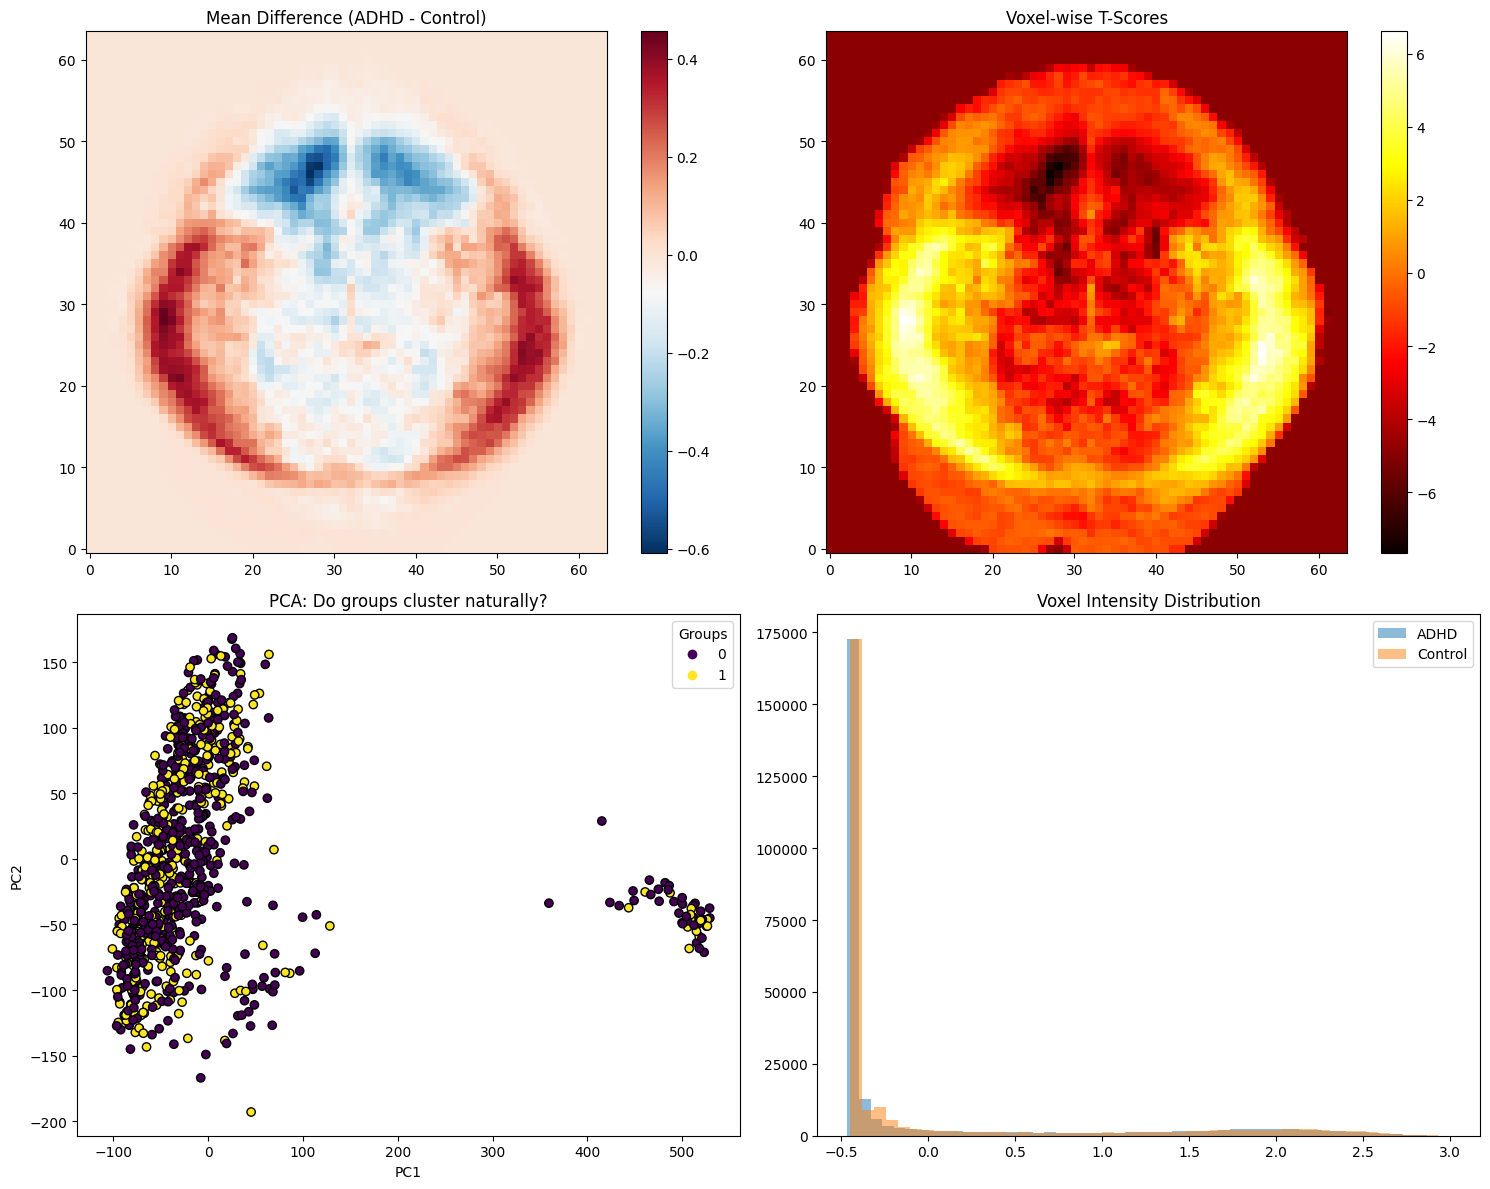

Analysis complete. Results saved to eda_results_ADHD


In [4]:
# 4. VISUALIZATION
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
slice_idx = diff.shape[2] // 2

# Plot Difference Map
im1 = axs[0, 0].imshow(diff[:, :, slice_idx].T, cmap='RdBu_r', origin='lower')
axs[0, 0].set_title("Mean Difference (ADHD - Control)")
fig.colorbar(im1, ax=axs[0, 0])

# Plot T-Score Map (Significance thresholded at |t| > 2 approx)
im2 = axs[0, 1].imshow(t_scores[:, :, slice_idx].T, cmap='hot', origin='lower')
axs[0, 1].set_title("Voxel-wise T-Scores")
fig.colorbar(im2, ax=axs[0, 1])

# Plot PCA Clusters
scatter = axs[1, 0].scatter(coords[:, 0], coords[:, 1], c=labels, cmap='viridis', edgecolors='k')
axs[1, 0].set_title("PCA: Do groups cluster naturally?")
axs[1, 0].set_xlabel("PC1")
axs[1, 0].set_ylabel("PC2")
legend = axs[1, 0].legend(*scatter.legend_elements(), title="Groups")

# Plot Distribution of Intensities
axs[1, 1].hist(m_adhd.flatten(), bins=50, alpha=0.5, label='ADHD')
axs[1, 1].hist(m_ctrl.flatten(), bins=50, alpha=0.5, label='Control')
axs[1, 1].set_title("Voxel Intensity Distribution")
axs[1, 1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "analysis_results.png"))
plt.show()

print(f"Analysis complete. Results saved to {OUTPUT_DIR}")


Most Significant Brain Clusters:
   Cluster ID           X          Y          Z  Peak Stat Cluster Size (mm3)
0           1  110.755012 -79.837518  32.138550   7.584655              26637
1          1a  104.755014 -82.962516   9.560480   7.543988                   
2          1b  112.755011 -81.400017  26.826063   7.054915                   
3          1c  106.755013 -73.587520  38.779159   6.799890                   
4           2   24.755043 -78.275018  32.138550   7.369877              27048
5          2a   30.755041 -65.775023  44.091646   6.901871                   
6          2b   26.755042 -84.525016  36.122916   6.896386                   
7          2c   26.755042 -89.212514  24.169819   6.868338                   
8           3   90.755019 -64.212524  17.529211   4.726924                 87
9          3a   96.755017 -70.462521  18.857332   3.572621                   
10          4   66.755028 -65.775023  37.451037   4.601199                112
11          5   66.755028 -98.

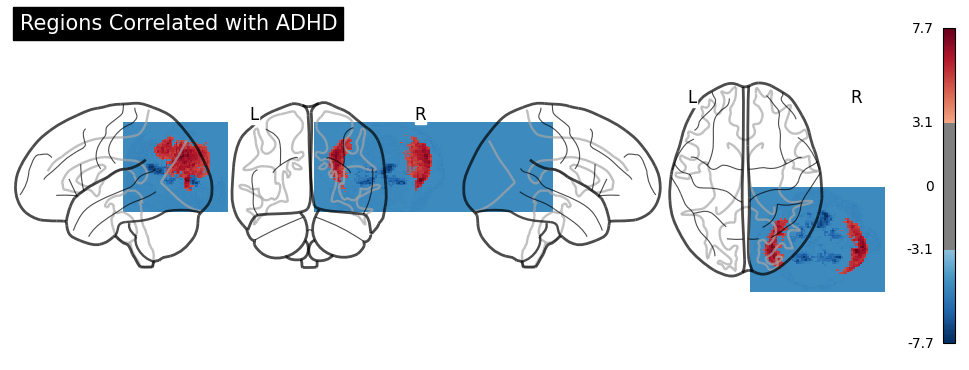

In [5]:
import nibabel as nib
from nilearn import plotting, datasets, reporting
from nilearn.image import new_img_like

# 1. Convert your T-score array back into a Nifti image
# We use the 'affine' captured during the EDA to ensure spatial alignment
t_map_nifti = new_img_like(nib.load(images[0]), t_scores)

# 2. Thresholding
# To identify 'strongly correlated' regions, we focus only on 
# high-significance voxels (e.g., T > 3.0 or T < -3.0)
threshold = 3.1  # Corresponds roughly to p < 0.001 uncorrected

# 3. Create a Publication-Quality Glass Brain
# This identifies which regions have the highest 'signal'
plotting.plot_glass_brain(
    t_map_nifti, 
    threshold=threshold, 
    colorbar=True, 
    display_mode='lyrz', 
    plot_abs=False,
    title='Regions Correlated with ADHD'
)

# 4. Extract the Anatomical Labels
# This uses an internal MNI atlas to tell you the name of the region
print("\nMost Significant Brain Clusters:")
table = reporting.get_clusters_table(
    t_map_nifti, 
    stat_threshold=threshold,
    cluster_threshold=10  # Minimum voxels to be considered a 'region'
)

print(table)

# 5. Save the table to CSV for your records
table.to_csv(os.path.join(OUTPUT_DIR, "significant_regions.csv"))

In [6]:
from nilearn import plotting
import os

# Create a subdirectory for individual cluster plots
clusters_dir = os.path.join(OUTPUT_DIR, "cluster_plots")
os.makedirs(clusters_dir, exist_ok=True)

print("Generating individual plots for significant clusters...")

# Iterate through the table
# We filter for only the 'main' clusters (e.g., 1, 2, 3) rather than sub-peaks (1a, 1b)
# to avoid generating 50+ nearly identical images.
main_clusters = table[~table['Cluster ID'].str.contains('[a-z]', na=False)]

for index, row in main_clusters.iterrows():
    cluster_id = row['Cluster ID']
    coords = [row['X'], row['Y'], row['Z']]
    peak_stat = row['Peak Stat']
    
    # Generate the filename
    fname = f"cluster_{cluster_id}_coord_{int(coords[0])}_{int(coords[1])}_{int(coords[2])}.png"
    save_path = os.path.join(clusters_dir, fname)
    
    # Create the plot
    display = plotting.plot_stat_map(
        t_map_nifti,
        display_mode='ortho',
        cut_coords=coords,
        title=f"Cluster {cluster_id} (Peak T={peak_stat:.2f})",
        threshold=3.0,
        draw_cross=True, # Shows exactly where the peak coordinate is
        colorbar=True,
        cmap='RdBu_r'
    )
    
    # Save and close to free up memory
    display.savefig(save_path)
    display.close()
    
    print(f" - Saved Plot for Cluster {cluster_id} at {coords}")

print(f"\nAll plots saved in: {clusters_dir}")

Generating individual plots for significant clusters...
 - Saved Plot for Cluster 1 at [110.75501203536987, -79.837517619133, 32.13855016231537]
 - Saved Plot for Cluster 2 at [24.755042791366577, -78.27501821517944, 32.13855016231537]
 - Saved Plot for Cluster 3 at [90.75501918792725, -64.21252357959747, 17.529210567474365]
 - Saved Plot for Cluster 4 at [66.7550277709961, -65.77502298355103, 37.4510372877121]
 - Saved Plot for Cluster 5 at [66.7550277709961, -98.58751046657562, 48.076011538505554]

All plots saved in: eda_results_ADHD\cluster_plots
